In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Data Requirements \Preprocessing
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

torch.manual_seed(42)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {train_size}, Validation size: {val_size}, Test size: {len(test_dataset)}")

Train size: 48000, Validation size: 12000, Test size: 10000


In [28]:
# Model Requirements(CNN)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Convolutional Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Fully Connected
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [27]:
#training \ evaluation
def train_and_evaluate(model, optimizer, criterion, epochs=10):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        #training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        #validation
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


def test_model(model):
    model.eval()
    correct, total = 0, 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    final_loss = test_loss / len(test_loader)
    print(f"Test Accuracy: {accuracy:.2f}% | Test Loss: {final_loss:.4f}")
    return accuracy, final_loss

In [ ]:
#experimentation
criterion = nn.CrossEntropyLoss()

#experiment 1:adam
print("\n Starting Experiment 1 (Model A: Adam Optimizer)")
model_A = SimpleCNN().to(device)
optimizer_A = optim.Adam(model_A.parameters(), lr=0.001)
exp1_train_loss, exp1_val_loss, exp1_train_acc, exp1_val_acc = train_and_evaluate(model_A, optimizer_A, criterion, epochs=10)
acc_A, loss_A = test_model(model_A)

#experiment 2:SGD
print("\n Starting Experiment 2 (Model B: SGD Optimizer)")
model_B = SimpleCNN().to(device)
optimizer_B = optim.SGD(model_B.parameters(), lr=0.01, momentum=0.9)
exp2_train_loss, exp2_val_loss, exp2_train_acc, exp2_val_acc = train_and_evaluate(model_B, optimizer_B, criterion, epochs=10)
acc_B, loss_B = test_model(model_B)


 Starting Experiment 1 (Model A: Adam Optimizer)
Epoch [1/10] - Train Loss: 0.2812, Acc: 91.41% | Val Loss: 0.0752, Acc: 97.74%
Epoch [2/10] - Train Loss: 0.1306, Acc: 96.14% | Val Loss: 0.0606, Acc: 98.18%
Epoch [3/10] - Train Loss: 0.1078, Acc: 96.82% | Val Loss: 0.0533, Acc: 98.41%
Epoch [4/10] - Train Loss: 0.0931, Acc: 97.16% | Val Loss: 0.0491, Acc: 98.63%
Epoch [5/10] - Train Loss: 0.0875, Acc: 97.37% | Val Loss: 0.0415, Acc: 98.80%
Epoch [6/10] - Train Loss: 0.0762, Acc: 97.69% | Val Loss: 0.0463, Acc: 98.74%
Epoch [7/10] - Train Loss: 0.0675, Acc: 98.06% | Val Loss: 0.0478, Acc: 98.64%
Epoch [8/10] - Train Loss: 0.0653, Acc: 98.07% | Val Loss: 0.0434, Acc: 98.83%
Epoch [9/10] - Train Loss: 0.0603, Acc: 98.12% | Val Loss: 0.0455, Acc: 98.69%
Epoch [10/10] - Train Loss: 0.0540, Acc: 98.34% | Val Loss: 0.0392, Acc: 98.95%
Test Accuracy: 99.30% | Test Loss: 0.0232

 Starting Experiment 2 (Model B: SGD Optimizer)
Epoch [1/10] - Train Loss: 0.2721, Acc: 91.56% | Val Loss: 0.0935, A

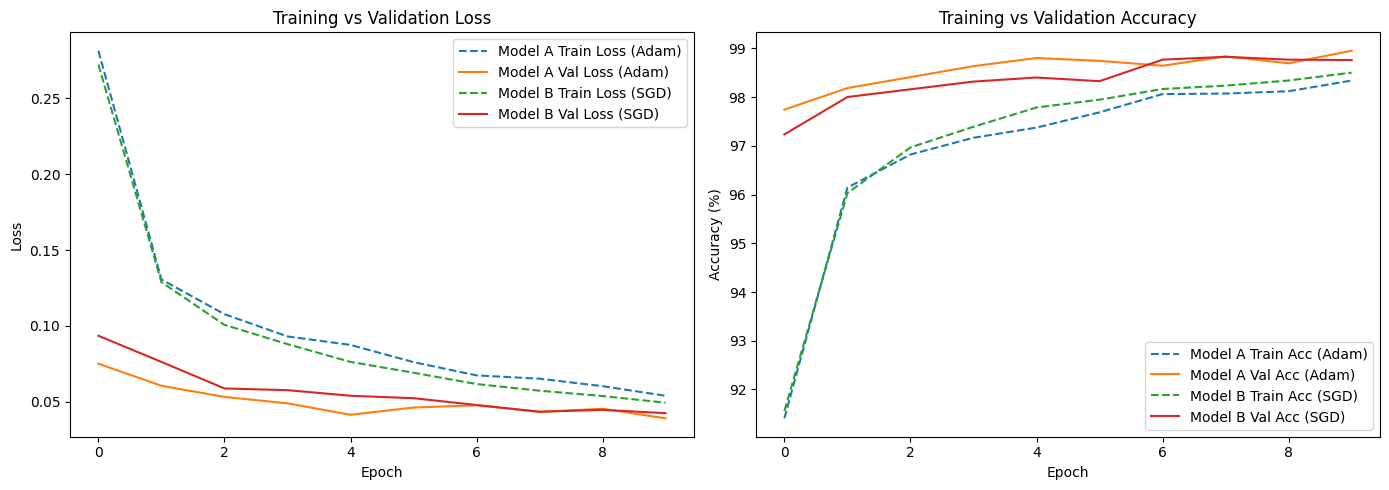


RESULTS COMPARISON TABLE
Model           | Accuracy   | Loss      
--------------------------------------------------
Model A (Adam)  | 99.30      | 0.0232    
Model B (SGD)   | 99.21      | 0.0242    


In [31]:
# Visualization Requirements
plt.figure(figsize=(14, 5))

# Plotting Loss Curves
plt.subplot(1, 2, 1)
plt.plot(exp1_train_loss, label='Model A Train Loss (Adam)', linestyle='--')
plt.plot(exp1_val_loss, label='Model A Val Loss (Adam)')
plt.plot(exp2_train_loss, label='Model B Train Loss (SGD)', linestyle='--')
plt.plot(exp2_val_loss, label='Model B Val Loss (SGD)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(exp1_train_acc, label='Model A Train Acc (Adam)', linestyle='--')
plt.plot(exp1_val_acc, label='Model A Val Acc (Adam)')
plt.plot(exp2_train_acc, label='Model B Train Acc (SGD)', linestyle='--')
plt.plot(exp2_val_acc, label='Model B Val Acc (SGD)')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()
#Results Requirements (Comparison Table)
print("\n" + "="*50)
print("RESULTS COMPARISON TABLE")
print("="*50)
print(f"{'Model':<15} | {'Accuracy':<10} | {'Loss':<10}")
print("-" * 50)
print(f"{'Model A (Adam)':<15} | {acc_A:<10.2f} | {loss_A:<10.4f}")
print(f"{'Model B (SGD)':<15} | {acc_B:<10.2f} | {loss_B:<10.4f}")
print("="*50)